# LUMOS evaluation

Loads one or more trained models, runs them over the test split of the store each
was trained on, and compares the recovered Raman against the ground truth and
against classical baseline correction.

Every model is paired with its own dataset: the wavenumber grid is fixed at
training time, so a model cannot be evaluated on a store with a different axis.

## Setup

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from pybaselines import polynomial, whittaker
from scipy.optimize import linear_sum_assignment
from scipy.signal import savgol_filter

import lumos
from lumos.metrics import pearson_r, psnr, scale_invariant_psnr, spectral_angle_mapper
from lumos.vae_module import VAEModule

In [16]:
# Resolved from the installed package so it does not depend on the kernel cwd.
CHECKPOINT_DIR = Path(lumos.__file__).resolve().parent / "checkpoints"
SPLIT = "test"

# "last" is the final state of a run. Use "best" to take the lowest
# val_recon_loss, which tracks reconstruction quality only loosely.
CHECKPOINT_SELECT = "last"

# Metrics use this window for every dataset so models trained on different
# crops stay comparable. None uses each store's full axis.
EVAL_WINDOW = (400.0, 1800.0)

DATA = Path("~/Developments/Raman/oracle/data/processed").expanduser()
GLASGOW = DATA / "glasgow/glasgow_16_trimmed_smoothed.zarr"
FISH = DATA / "fish/fish_6frame.zarr"
BIO = DATA / "bio/bio_16_noisy.zarr"

# One entry per model, paired with the store it was trained on. Labels key every
# result dict, so they must be unique: name the setting under test rather than
# the dataset, or a second entry silently replaces the first.
#
# The four fish runs all use fixed T (t_sampling=""), cosine over 1000 epochs and
# mean pooling, differing only in frames seen and whether the test spectra were
# in the fitting pool. At 6 frames the encoder has already seen the final frame,
# so those models reconstruct it rather than extrapolating to it.
RUNS = [
    dict(label="fish 3f inductive", zarr=FISH,
         run="fish_6frame_mog_t3_z64_h128_lr0.0005_20260825_160257"),
    dict(label="fish 6f inductive", zarr=FISH,
         run="fish_6frame_mog_t6_z64_h128_lr0.0005_20260825_160303"),
    dict(label="fish 3f transductive", zarr=FISH,
         run="fish_6frame_mog_t3_z64_h128_lr0.0005_20260825_161453"),
    dict(label="fish 6f transductive", zarr=FISH,
         run="fish_6frame_mog_t6_z64_h128_lr0.0005_20260825_161459"),
    # Variable T and wider (z128/h512), so this one accepts fewer than 16 frames.
    dict(label="glasgow 16f var T", zarr=GLASGOW,
         run="glasgow_16_trimmed_smoothed_mog_t16_z128_h512_lr0.0005_20260825_153805"),
]

# Classical baselines, computed once per dataset.
SAVGOL_WINDOW, SAVGOL_ORDER = 11, 3
AIRPLS_LAM, IMODPOLY_ORDER = 1e6, 5

print(f"checkpoints: {CHECKPOINT_DIR}")

checkpoints: /home/tom/Developments/lumos/src/lumos/checkpoints


## Helpers

In [17]:
def best_checkpoint(run_dir, select=CHECKPOINT_SELECT):
    """Path to one checkpoint in a run directory.

    "last" takes last.ckpt, "best" the epoch file with the lowest
    val_recon_loss. Falls back to whichever exists.
    """
    run_dir = Path(run_dir)
    if not run_dir.is_dir():
        available = sorted(p.name for p in CHECKPOINT_DIR.iterdir() if p.is_dir())
        raise FileNotFoundError(
            f"no run directory {run_dir}\navailable:\n  " + "\n  ".join(available[-10:])
        )
    last = run_dir / "last.ckpt"
    epochs = sorted(run_dir.glob("epoch=*.ckpt"))
    if select == "last" and last.exists():
        return last
    if epochs:
        return min(epochs, key=lambda f: float(f.stem.split("val_recon_loss=")[1]))
    if last.exists():
        return last
    raise FileNotFoundError(f"no checkpoints in {run_dir}")


def load_model(run):
    path = best_checkpoint(CHECKPOINT_DIR / run)
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    # Checkpoints predating decoder_dim need it inferred from the weights.
    decoder_dim = ckpt["state_dict"]["model.decoder.trunk_shared.0.weight"].shape[0]
    model = VAEModule.load_from_checkpoint(
        path,
        map_location="cuda" if torch.cuda.is_available() else "cpu",
        strict=False,
        decoder_dim=decoder_dim,
    )
    model.eval()
    return model, ckpt["hyper_parameters"], path.name

In [18]:
def load_data(zarr_path, split=SPLIT):
    """Read one split of a store into plain arrays.

    Ground-truth fields are present in synthetic stores and in the real ones
    that ship a derived reference; the identification metrics need the
    fluorophore-level fields and are skipped without them.
    """
    ds = xr.open_zarr(str(zarr_path))
    idx = np.where(ds["split"].values == split)[0]
    frame_duration = float(ds.attrs.get("frame_duration_s", 0.1))
    gt_var = "gt_raman_smoothed" if "gt_raman_smoothed" in ds else "gt_raman"

    def optional(name):
        return ds[name].values[idx] if name in ds else None

    return dict(
        name=Path(str(zarr_path)).name,
        idx=idx,
        frame_duration=frame_duration,
        wn=ds.coords["wavenumber"].values,
        ts=ds["time_series"].values[idx],
        gt=ds[gt_var].values[idx] / frame_duration,
        labels=np.array([str(v) for v in ds["labels"].values[idx]]),
        n_early=ds["n_early_actual"].values[idx],
        long_exposure=ds["input_long_exposure"].values[idx],
        bases_gt=optional("fluorophore_bases_gt"),
        rates_gt=optional("decay_rates_gt"),
        abund_gt=optional("abundances_gt"),
        dye_names=optional("fluorophore_name"),
    )

In [19]:
def predict_lumos(model, data, batch=8):
    """Recovered Raman, decay rates and abundances for every spectrum."""
    n_times = model.hparams.n_times_train
    std = model.model.dataset_std
    device = next(model.parameters()).device
    raman, rates, abundances = [], [], []
    with torch.no_grad():
        for i in range(0, len(data["ts"]), batch):
            x = data["ts"][i:i + batch, :, :n_times].astype(np.float32)
            x = torch.from_numpy(x).to(device) / std
            _, _, _, lam, ab, ram, _ = model.model(x, sample=False)
            raman.append(ram.cpu().numpy())
            rates.append(lam.cpu().numpy())
            abundances.append(ab.cpu().numpy())
    return tuple(np.concatenate(v, 0) for v in (raman, rates, abundances))


def debaseline(spectra, method="airpls", smooth=True):
    """Remove a smooth background from each spectrum.

    smooth=True also applies a Savitzky-Golay filter, which is what the
    classical baseline methods do as a correction pipeline. For metrics use
    smooth=False, so the comparison is not blurred as well as detrended.
    """
    out = np.empty_like(spectra, dtype=np.float64)
    for i, s in enumerate(spectra):
        s = s.astype(np.float64)
        if smooth:
            s = savgol_filter(s, SAVGOL_WINDOW, SAVGOL_ORDER)
        if method == "airpls":
            base, _ = whittaker.iarpls(s, lam=AIRPLS_LAM)
        else:
            base, _ = polynomial.imodpoly(s, poly_order=IMODPOLY_ORDER)
        out[i] = s - base
    return out


def eval_mask(wn):
    """Restrict a wavenumber axis to the common evaluation window."""
    if EVAL_WINDOW is None:
        return np.ones(len(wn), dtype=bool)
    return (wn >= EVAL_WINDOW[0]) & (wn <= EVAL_WINDOW[1])

## Load models and predict

`datasets` is keyed by store name, `predictions` by `(store, method)`, and
`model_info` by model label. Each model's own dataset is stored alongside it so
later cells do not have to look it up.

In [20]:
datasets, predictions, model_info, latents = {}, {}, {}, {}

labels = [cfg["label"] for cfg in RUNS]
duplicates = {lab for lab in labels if labels.count(lab) > 1}
if duplicates:
    raise ValueError(f"RUNS labels must be unique, repeated: {sorted(duplicates)}")

for cfg in RUNS:
    name = Path(str(cfg["zarr"])).name
    if name not in datasets:
        datasets[name] = load_data(cfg["zarr"])
        d = datasets[name]
        # Classical correction of the long exposure: the store's precomputed sum
        # of the first n_early frames, as counts per second. Photon-matched to a
        # model that sees all n_early frames, generous to one that sees fewer,
        # so a matched baseline is added per model below.
        rate = d["long_exposure"] / (d["n_early"][:, None] * d["frame_duration"])
        predictions[(name, "iAirPLS (long exp)")] = debaseline(rate, "airpls")
        predictions[(name, "iModPoly (long exp)")] = debaseline(rate, "imodpoly")
        print(f"{name}: {len(d['idx'])} samples, W={len(d['wn'])}")

    d = datasets[name]
    model, hparams, ckpt = load_model(cfg["run"])
    if hparams["n_wavenumbers"] != len(d["wn"]):
        raise ValueError(
            f"{cfg['label']}: model expects W={hparams['n_wavenumbers']} but "
            f"{name} has W={len(d['wn'])}. Pair each model with its own store."
        )
    raman, rates, abundances = predict_lumos(model, d)
    predictions[(name, cfg["label"])] = raman
    latents[cfg["label"]] = dict(rates=rates, abundances=abundances)
    model_info[cfg["label"]] = dict(
        model=model, hparams=hparams, data=d, checkpoint=ckpt,
        n_fluorophores=hparams.get("n_fluorophores"),
        decay_mode=hparams.get("decay_mode", "per_sample"),
    )
    # Classical baseline on exactly the frames this model saw, so the two are
    # compared at the same photon budget.
    n_t = hparams["n_times_train"]
    if (name, f"iAirPLS ({n_t}f)") not in predictions:
        matched = d["ts"][:, :, :n_t].sum(2) / (n_t * d["frame_duration"])
        predictions[(name, f"iAirPLS ({n_t}f)")] = debaseline(matched, "airpls")
        predictions[(name, f"iModPoly ({n_t}f)")] = debaseline(matched, "imodpoly")

    print(f"  {cfg['label']:22s} F={hparams.get('n_fluorophores'):<3} "
          f"T={hparams.get('n_times_train'):<3} "
          f"t_sampling={hparams.get('t_sampling', '') or 'fixed':<8} <- {ckpt}")

glasgow_16_trimmed_smoothed.zarr: 54 samples, W=593
[VAE init] raman_mode=pseudo_voigt  n_raman_peaks=300
[VAE init] head_abundance: weight_norm=5.627  bias=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  (softplus -> [0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996, 0.6931471824645996])
  glasgow new            F=16  T=16  t_sampling=uniform  <- last.ckpt


## Metrics

Recovered Raman against `gt_raman`, over the evaluation window, reported two
ways.

**As recovered** compares the raw spectra. On real stores `gt_raman` is derived
rather than measured, and on fish it is not fully bleached, so it still carries
some fluorescence. A model that leaves fluorescence in its Raman output scores
*better* on that target than it should, which inverts the ranking: a badly
fitted fish model scores Pearson 0.572 here against 0.556 for a good one.

**Baseline removed** strips a smooth background from both sides with airPLS
before comparing, so only peak agreement is scored. On the same two fish models
that gives 0.620 and 0.911, in the right order. This is the row to trust wherever
the target is a derived reference rather than a true Raman spectrum.

In [21]:
METRICS = {
    "PSNR": psnr,
    "SI-PSNR": scale_invariant_psnr,
    "Pearson": pearson_r,
    "SAM": spectral_angle_mapper,
}


def score(gt, pred):
    return {k: np.mean([fn(gt[i], pred[i]) for i in range(len(gt))])
            for k, fn in METRICS.items()}


rows = []
for (name, method), pred in predictions.items():
    d = datasets[name]
    mask = eval_mask(d["wn"])
    gt, pr = d["gt"][:, mask], pred[:, mask]
    for (a, b), tag in [((gt, pr), "as recovered"),
                        ((debaseline(gt, smooth=False),
                          debaseline(pr, smooth=False)), "baseline removed")]:
        rows.append(dict(dataset=name, target=tag, method=method,
                         W=int(mask.sum()), **score(a, b)))

results = pd.DataFrame(rows).set_index(["dataset", "target", "method"]).sort_index()
print(f"window {EVAL_WINDOW} cm^-1" if EVAL_WINDOW else "full axis")
results.round(3)

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._iarpls(y, baseline, i)


window (400.0, 1800.0) cm^-1


/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/pybaselines/whittaker.py:490: ParameterWarning: almost all baseline points are below the data, indicating that "tol" is too low and/or "max_iter" is too high
  new_weights, exit_early = _weighting._iarpls(y, baseline, i)


W    PSNR  \
dataset                          target           method                        
glasgow_16_trimmed_smoothed.zarr as recovered     glasgow new     593  18.398   
                                                  iAirPLS (sum)   593  17.586   
                                                  iModPoly (sum)  593  15.241   
                                 baseline removed glasgow new     593  19.515   
                                                  iAirPLS (sum)   593  18.312   
                                                  iModPoly (sum)  593  19.196   

                                                                  SI-PSNR  \
dataset                          target           method                    
glasgow_16_trimmed_smoothed.zarr as recovered     glasgow new      22.937   
                                                  iAirPLS (sum)    22.498   
                                                  iModPoly (sum)   19.824   
                                 baseline removed glasgow new      22.859   
                                                  iAirPLS (sum)    22.602   
                                                  iModPoly (sum)   22.083   

                                                                  Pearson  \
dataset                          target           method                    
glasgow_16_trimmed_smoothed.zarr as recovered     glasgow new       0.918   
                                                  iAirPLS (sum)     0.885   
                                                  iModPoly (sum)    0.863   
                                 baseline removed glasgow new       0.916   
                                                  iAirPLS (sum)     0.897   
                                                  iModPoly (sum)    0.913   

                                                                     SAM  
dataset                          target           method                  
glasgow_16_trimmed_smoothed.zarr as recovered     glasgow new     17.843  
                                                  iAirPLS (sum)   19.438  
                                                  iModPoly (sum)  32.767  
                                 baseline removed glasgow new     17.404  
                                                  iAirPLS (sum)   18.610  
                                                  iModPoly (sum)  18.349

## Recovered spectra

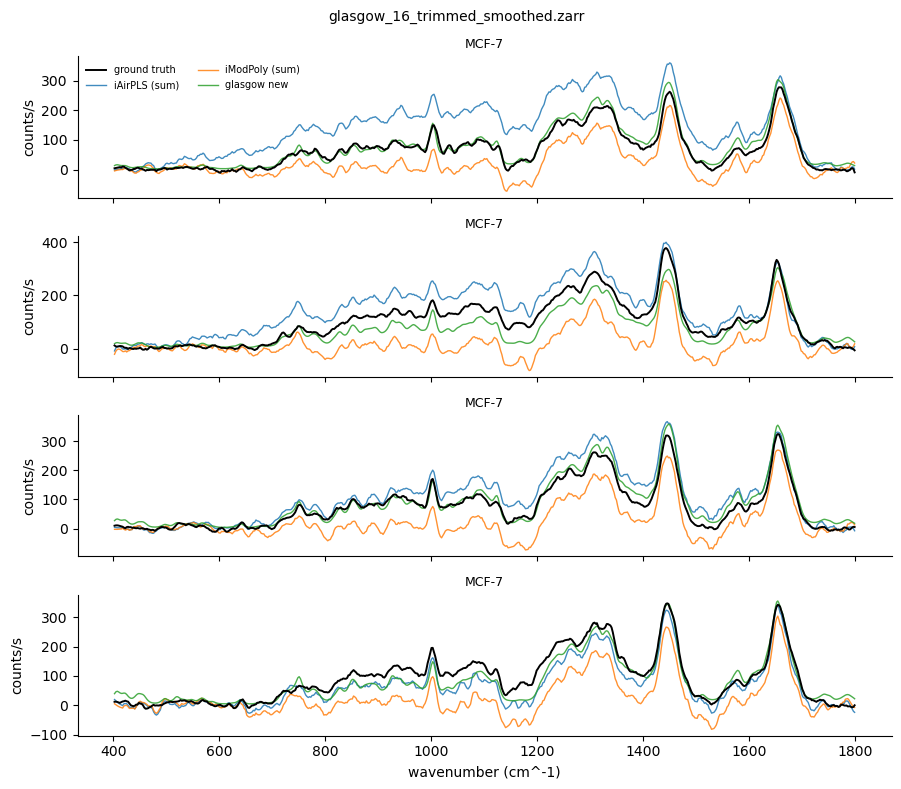

In [22]:
N_SHOW = 4

for name, d in datasets.items():
    methods = [(key[1], pred) for key, pred in predictions.items() if key[0] == name]
    mask = eval_mask(d["wn"])
    fig, axes = plt.subplots(N_SHOW, 1, figsize=(9, 2.0 * N_SHOW), sharex=True)
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.plot(d["wn"][mask], d["gt"][i][mask], color="black", lw=1.4,
                label="ground truth", zorder=5)
        for method, pred in methods:
            ax.plot(d["wn"][mask], pred[i][mask], lw=1.0, alpha=0.85, label=method)
        ax.set_ylabel("counts/s")
        ax.set_title(d["labels"][i], fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].legend(fontsize=7, frameon=False, ncol=2)
    axes[-1].set_xlabel("wavenumber (cm^-1)")
    fig.suptitle(name, fontsize=10)
    plt.tight_layout()
    plt.show()

## Decomposition detail

Six panels for a single spectrum: the input frames, the fit, the Raman and
fluorescence split at `t=0`, how each component decays, the learned bases, and
the reconstruction error over time.

The fluorescence is built from the model's own components rather than by
subtracting the Raman from the input, so the three curves in the third panel are
independent predictions and their sum is a genuine check.

In [23]:
def visualise_decomposition(label, sample=0, crop=EVAL_WINDOW, n_show=None):
    """Decomposition of one spectrum. n_show limits components, largest first."""
    info = model_info[label]
    m, d = info["model"], info["data"]
    wn, fd = d["wn"], d["frame_duration"]
    mask = eval_mask(wn) if crop is not None else np.ones(len(wn), bool)
    n_times = m.hparams.n_times_train
    std = m.model.dataset_std
    device = next(m.parameters()).device

    x = torch.from_numpy(d["ts"][sample].astype(np.float32)).to(device) / std  # [W, T]
    t_all = m.t_full.detach().cpu().numpy()
    n_t = min(x.shape[1], len(t_all))

    with torch.no_grad():
        _, _, _, lam, ab, raman, bases = m.model(x[None, :, :n_times], sample=False)
        recon, _ = m.model.physics_forward(
            lam, ab, raman, bases, time_values=m.t_full[:n_t].to(device)
        )

    # physics_forward already returns physical counts per frame.
    recon = recon[0].T.cpu().numpy()                 # [T, W]
    observed = (x.T.cpu().numpy() * std)[:n_t]       # [T, W]
    raman_frame = raman[0].cpu().numpy() * fd        # counts/frame
    bases_np = bases.cpu().numpy()
    lam_np, ab_np = lam[0].cpu().numpy(), ab[0].cpu().numpy()

    # fluorescence(t) = sum_i a_i * B_i(nu) * exp(-lambda_i * t)
    decay = np.exp(-lam_np[None, :] * t_all[:n_t, None])   # [T, F]
    component = ab_np[:, None] * bases_np                  # [F, W]
    fluorescence = decay @ component                       # [T, W]

    closure = np.abs(observed[0] - (raman_frame + fluorescence[0])).mean()
    print(f"{label} sample {sample}: mean |observed - (raman + fluorescence)| "
          f"at t=0 = {closure:.3f} counts")

    order = np.argsort(-ab_np)
    k = len(order) if n_show is None else min(n_show, len(order))
    colours = plt.cm.viridis(np.linspace(0, 0.9, n_t))
    fig, ax = plt.subplots(2, 3, figsize=(17, 8))

    a = ax[0, 0]
    for t in range(n_t):
        a.plot(wn[mask], observed[t][mask], color=colours[t], lw=0.7, alpha=0.75)
    a.set(title=f"input, {n_t} frames (dark = early)", ylabel="counts/frame")

    a = ax[0, 1]
    for t in range(0, n_t, max(1, n_t // 6)):
        a.plot(wn[mask], observed[t][mask], color=colours[t], lw=0.8, alpha=0.6)
        a.plot(wn[mask], recon[t][mask], color=colours[t], lw=0.9, ls="--")
    a.plot([], [], "k-", label="observed")
    a.plot([], [], "k--", label="reconstructed")
    a.legend(fontsize=7, frameon=False)
    a.set(title="fit")

    a = ax[0, 2]
    a.plot(wn[mask], observed[0][mask], color="0.6", lw=1.0, label="observed t=0")
    a.plot(wn[mask], fluorescence[0][mask], color="tab:blue", lw=1.2, label="fluorescence")
    a.plot(wn[mask], raman_frame[mask], color="tab:orange", lw=1.4, label="Raman")
    a.plot(wn[mask], (raman_frame + fluorescence[0])[mask], color="tab:green",
           lw=0.9, ls="--", label="sum")
    a.plot(wn[mask], d["gt"][sample][mask] * fd, color="black", lw=1.0, ls=":",
           label="ground-truth Raman")
    a.legend(fontsize=7, frameon=False)
    a.set(title="decomposition at t=0")

    a = ax[1, 0]
    for i in order[:k]:
        a.plot(t_all[:n_t], decay[:, i] * component[i].sum(), lw=1.2,
               label=f"c{i}  {lam_np[i]:.2f} s^-1")
    a.plot(t_all[:n_t], fluorescence.sum(1), "k-", lw=1.6, label="total")
    a.axvline(t_all[n_times - 1], color="k", ls=":", lw=1)
    a.text(t_all[n_times - 1], a.get_ylim()[1], " end of training window",
           fontsize=6, va="top")
    a.legend(fontsize=6, frameon=False, ncol=2)
    a.set(title="component decay", xlabel="time (s)")

    a = ax[1, 1]
    for i in order[:k]:
        a.plot(wn[mask], (bases_np[i] / bases_np[i].max())[mask], lw=1.0, label=f"c{i}")
    if d["bases_gt"] is not None:
        for g in d["bases_gt"][sample]:
            a.plot(wn[mask], (g / g.max())[mask], color="black", lw=0.9, ls="--", alpha=0.7)
        a.plot([], [], "k--", label="true")
    a.legend(fontsize=6, frameon=False, ncol=2)
    a.set(title="bases (peak-normalised)")

    a = ax[1, 2]
    a.semilogy(t_all[:n_t], ((observed - recon) ** 2).mean(1), "k-", lw=1.2)
    a.axvline(t_all[n_times - 1], color="k", ls=":", lw=1)
    a.set(title="reconstruction MSE over time", xlabel="time (s)")

    for a in ax.ravel():
        a.spines[["top", "right"]].set_visible(False)
        a.tick_params(labelsize=7)
        if not a.get_xlabel():
            a.set_xlabel("wavenumber (cm^-1)", fontsize=7)
    fig.suptitle(f"{label}  |  sample {sample} ({d['labels'][sample]})", fontsize=10)
    plt.tight_layout()
    plt.show()

glasgow new sample 10: mean |observed - (raman + fluorescence)| at t=0 = 8.801 counts


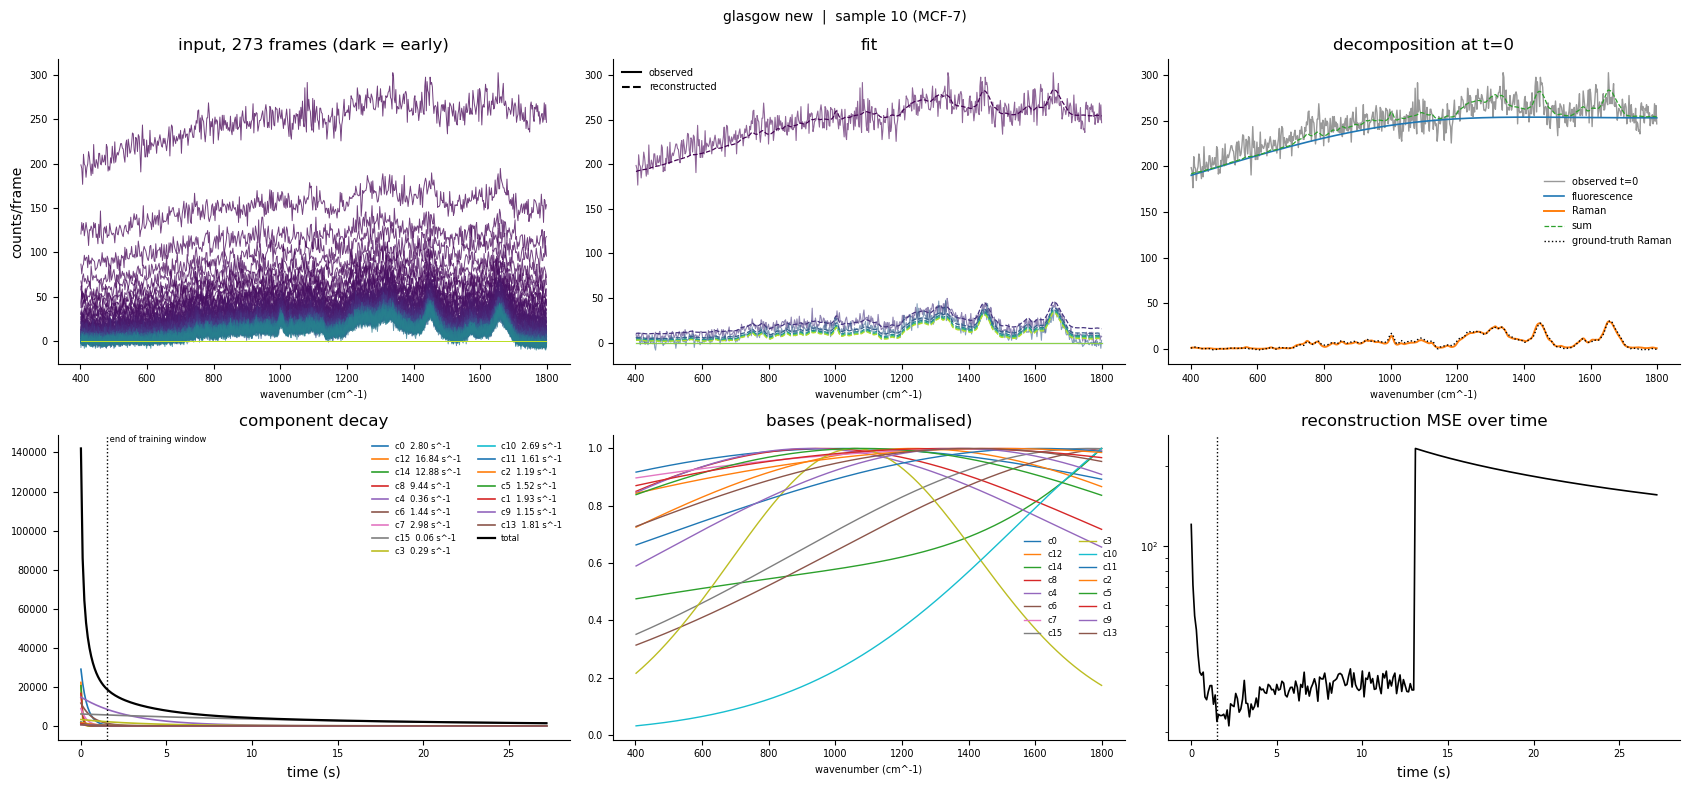

In [24]:
for label in model_info:
    visualise_decomposition(label, sample=10)

## Learned fluorophore bases

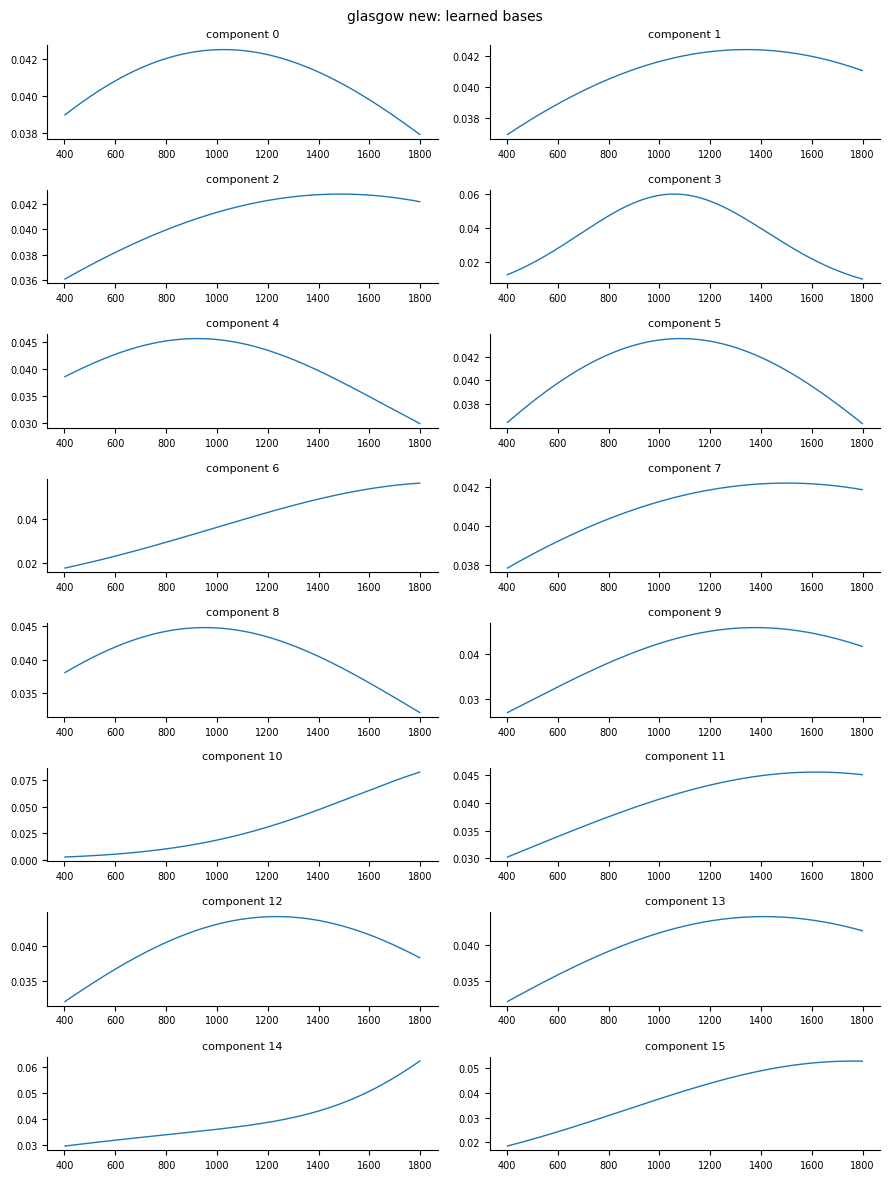

In [25]:
for label, info in model_info.items():
    m = info["model"]
    bases = m.model.bases.detach().cpu().numpy()
    wn = m.model.wavenumbers.detach().cpu().numpy()
    rates = None
    if hasattr(m.model, "log_lambda_global"):
        rates = torch.nn.functional.softplus(
            m.model.log_lambda_global.detach()
        ).cpu().numpy()

    n = bases.shape[0]
    ncol = 2
    fig, axes = plt.subplots(int(np.ceil(n / ncol)), ncol,
                             figsize=(9, 1.5 * n / ncol), squeeze=False)
    for i, ax in enumerate(axes.ravel()[:n]):
        ax.plot(wn, bases[i], lw=1.0)
        title = f"component {i}"
        if rates is not None:
            title += f"   {rates[i]:.3f} s^-1"
        ax.set_title(title, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=7)
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)
    fig.suptitle(f"{label}: learned bases", fontsize=10)
    plt.tight_layout()
    plt.show()

## Fluorophore identification

Synthetic stores only, since it needs per-sample ground-truth fluorophores.
Components are matched to true fluorophores by the Hungarian assignment on
cosine similarity.

Cosine between broad non-negative spectra saturates near 1 and says little, so
the rate and abundance correlations are the informative numbers.

In [26]:
identification = {}

for label, info in model_info.items():
    d = info["data"]
    if d["bases_gt"] is None:
        print(f"{label}: no ground-truth fluorophores in {d['name']}, skipping")
        continue

    bases = info["model"].model.bases.detach().cpu().numpy()
    bases_n = bases / (np.linalg.norm(bases, axis=1, keepdims=True) + 1e-9)
    rates, abundances = latents[label]["rates"], latents[label]["abundances"]

    cos, true_rate, pred_rate, true_ab, pred_ab = [], [], [], [], []
    for n in range(len(d["idx"])):
        g = d["bases_gt"][n]
        g = g / (np.linalg.norm(g, axis=1, keepdims=True) + 1e-9)
        similarity = g @ bases_n.T
        row, col = linear_sum_assignment(-similarity)
        cos.append(similarity[row, col])
        true_rate.append(d["rates_gt"][n][row])
        pred_rate.append(rates[n][col])
        true_ab.append(d["abund_gt"][n][row] / d["abund_gt"][n].sum())
        pred_ab.append(abundances[n][col] / (abundances[n][col].sum() + 1e-12))

    cos = np.concatenate(cos)
    pairs = tuple(np.concatenate(v) for v in (true_rate, pred_rate, true_ab, pred_ab))
    identification[label] = dict(pairs=pairs, bases=bases, wn=d["wn"])

    gr, pr, ga, pa = pairs
    print(f"{label}   ({bases.shape[0]} model components)")
    print(f"  matched cosine     {cos.mean():.4f}   (saturates, of limited use)")
    print(f"  log rate r         {np.corrcoef(np.log(gr), np.log(pr))[0, 1]:+.4f}")
    print(f"  abundance r        {np.corrcoef(ga, pa)[0, 1]:+.4f}")

glasgow new: no ground-truth fluorophores in glasgow_16_trimmed_smoothed.zarr, skipping


In [27]:
for label, r in identification.items():
    gr, pr, ga, pa = r["pairs"]
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))

    lim = [min(gr.min(), pr.min()), max(gr.max(), pr.max())]
    ax[0].loglog(gr, pr, ".", ms=4, alpha=0.5)
    ax[0].plot(lim, lim, "k--", lw=1)
    ax[0].set(xlabel="true rate (s^-1)", ylabel="predicted",
              title=f"decay rates  r={np.corrcoef(np.log(gr), np.log(pr))[0, 1]:+.3f}")

    ax[1].plot(ga, pa, ".", ms=4, alpha=0.5)
    ax[1].plot([0, 1], [0, 1], "k--", lw=1)
    ax[1].set(xlabel="true fraction", ylabel="predicted",
              title=f"abundance  r={np.corrcoef(ga, pa)[0, 1]:+.3f}")

    for b in r["bases"]:
        ax[2].plot(r["wn"], b / b.max(), lw=0.9)
    ax[2].set(xlabel="wavenumber (cm^-1)",
              title=f"{r['bases'].shape[0]} learned bases")

    for a in ax:
        a.spines[["top", "right"]].set_visible(False)
    fig.suptitle(label, fontsize=10)
    plt.tight_layout()
    plt.show()

### Matched pairs

In [28]:
N_SAMPLES = 6

for label, info in model_info.items():
    d = info["data"]
    if d["bases_gt"] is None:
        continue
    bases = info["model"].model.bases.detach().cpu().numpy()
    bases_n = bases / (np.linalg.norm(bases, axis=1, keepdims=True) + 1e-9)
    n_fluo = d["bases_gt"].shape[1]

    fig, axes = plt.subplots(N_SAMPLES, n_fluo,
                             figsize=(4 * n_fluo, 2.2 * N_SAMPLES), squeeze=False)
    picks = np.linspace(0, len(d["idx"]) - 1, N_SAMPLES, dtype=int)
    for si, n in enumerate(picks):
        g = d["bases_gt"][n]
        g = g / (np.linalg.norm(g, axis=1, keepdims=True) + 1e-9)
        similarity = g @ bases_n.T
        row, col = linear_sum_assignment(-similarity)
        for k in range(min(n_fluo, len(row))):
            ax = axes[si, k]
            true = d["bases_gt"][n][row[k]]
            pred = bases[col[k]]
            ax.plot(d["wn"], true / true.max(), color="black", lw=1.2, label="true")
            ax.plot(d["wn"], pred / pred.max(), color="tab:orange", lw=1.2,
                    ls="--", label="learned")
            name = str(d["dye_names"][n][row[k]]) if d["dye_names"] is not None else ""
            ax.set_title(f"{name}  cos={similarity[row[k], col[k]]:.3f}", fontsize=8)
            ax.spines[["top", "right"]].set_visible(False)
            if si == 0 and k == 0:
                ax.legend(fontsize=7, frameon=False)
    fig.suptitle(f"{label}: true fluorophore against its assigned component", fontsize=10)
    plt.tight_layout()
    plt.show()

## Learned representations

Five per-sample representations from each model. Classes are only meaningful
where a store has few distinct labels; with one label per sample (fish spot IDs,
for instance) points are coloured by initial intensity instead.

In [29]:
def representations(label):
    """Per-sample latent, abundances, rates, fluorescence and Raman."""
    info = model_info[label]
    m, d = info["model"], info["data"]
    n_times = m.hparams.n_times_train
    std = m.model.dataset_std
    device = next(m.parameters()).device

    rates, abundances, raman, mu = [], [], [], []
    with torch.no_grad():
        for i in range(0, len(d["ts"]), 8):
            x = d["ts"][i:i + 8, :, :n_times].astype(np.float32)
            x = torch.from_numpy(x).to(device) / std
            _, _, _, lam, ab, ram, _ = m.model(x, sample=False)
            rates.append(lam.cpu().numpy())
            abundances.append(ab.cpu().numpy())
            raman.append(ram.cpu().numpy())
            mu.append(m.model.encoder(
                x, m.model.wn_norm, m.model.t_norm_full[:n_times]
            )[0].cpu().numpy())

    rates, abundances, raman, mu = (
        np.concatenate(v) for v in (rates, abundances, raman, mu)
    )
    bases = m.model.bases.detach().cpu().numpy()
    fluorescence = (abundances[:, :, None] * bases[None]).sum(1)  # at t=0

    def unit(v):
        return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)

    return dict(
        label=label,
        data=d,
        reps={
            "latent mu": mu,
            "abundances": abundances / (abundances.sum(1, keepdims=True) + 1e-12),
            "decay rates": np.log(rates),
            "fluorescence": unit(fluorescence),
            "recovered Raman": unit(raman),
        },
    )


reps = {label: representations(label) for label in model_info}
for label, r in reps.items():
    n_classes = len(set(r["data"]["labels"]))
    note = "  (one label per sample, no class structure)" if n_classes > 20 else ""
    print(f"{label:26s} {len(r['data']['labels']):>4} samples, "
          f"{n_classes:>3} distinct labels{note}")

glasgow new                  54 samples,   4 distinct labels


### PCA and UMAP

/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/tom/miniconda3/envs/ML/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/

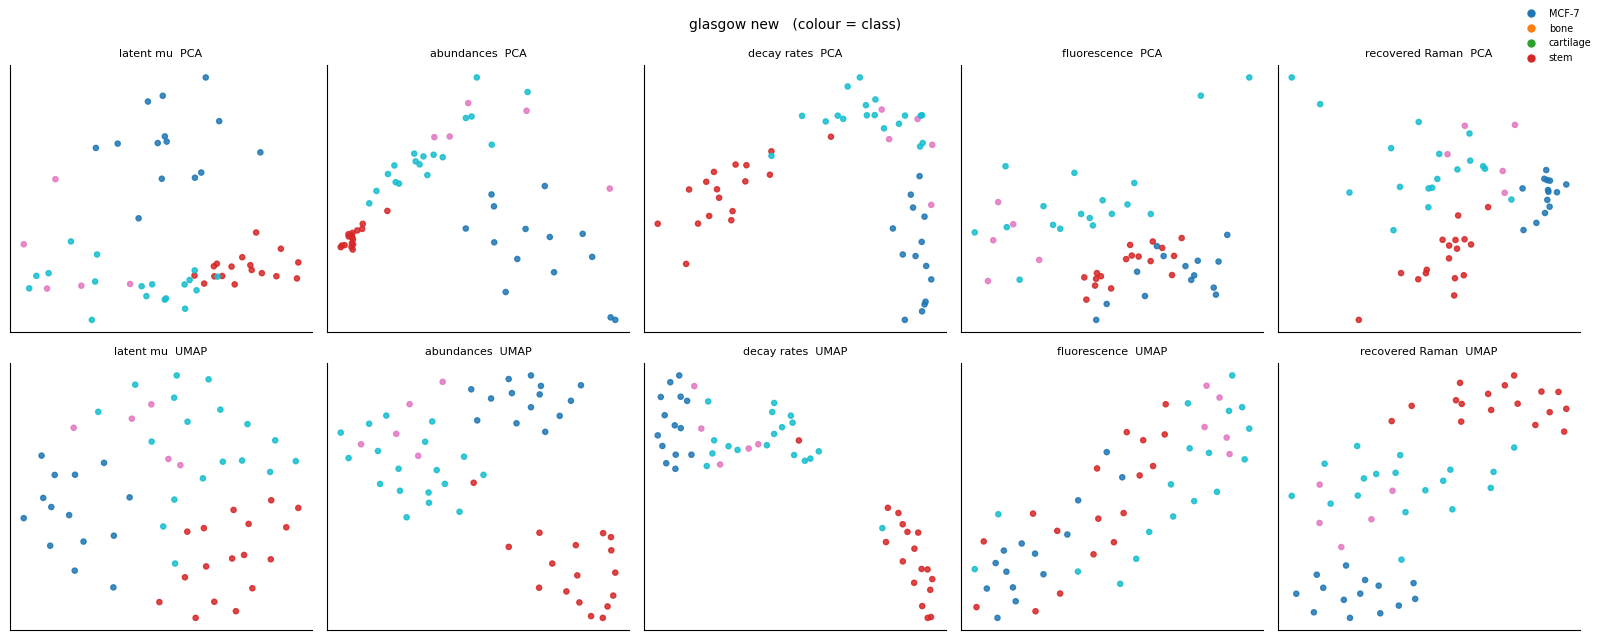

In [30]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

for label, r in reps.items():
    classes = r["data"]["labels"]
    n_classes = len(set(classes))
    has_classes = n_classes <= 20
    colour = (pd.Categorical(classes).codes if has_classes
              else r["data"]["ts"][:, :, 0].mean(1))

    names = list(r["reps"])
    fig, ax = plt.subplots(2, len(names), figsize=(3.2 * len(names), 6.4), squeeze=False)
    for j, name in enumerate(names):
        Z = StandardScaler().fit_transform(r["reps"][name])
        embeddings = [
            (PCA(2).fit_transform(Z), "PCA"),
            (umap.UMAP(n_components=2, random_state=0,
                       n_neighbors=min(15, len(Z) - 1)).fit_transform(Z), "UMAP"),
        ]
        for i, (proj, tag) in enumerate(embeddings):
            a = ax[i, j]
            a.scatter(proj[:, 0], proj[:, 1], c=colour,
                      cmap="tab10" if has_classes else "viridis", s=14, alpha=0.85)
            a.set_title(f"{name}  {tag}", fontsize=8)
            a.set_xticks([])
            a.set_yticks([])
            a.spines[["top", "right"]].set_visible(False)

    if has_classes:
        handles = [plt.Line2D([0], [0], marker="o", ls="", markersize=5,
                              color=plt.cm.tab10(i / 10), label=c)
                   for i, c in enumerate(sorted(set(classes)))]
        fig.legend(handles=handles, loc="upper right", fontsize=7, frameon=False)
    source = "class" if has_classes else "initial intensity"
    fig.suptitle(f"{label}   (colour = {source})", fontsize=10)
    plt.tight_layout()
    plt.show()

### Class information

Cross-validated LDA on each representation. A caveat worth remembering: LDA on
high-dimensional spectra separates even random labels almost perfectly when fit
and scored on the same data, so the cross-validation here is essential, and no
representation can carry more class information than the raw input it came from.

In [144]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

for label, r in reps.items():
    classes = r["data"]["labels"]
    if len(set(classes)) > 20:
        print(f"{label}: {len(set(classes))} distinct labels, no class structure to score")
        continue

    majority = max(np.mean(classes == c) for c in set(classes))
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    print(f"\n{label}   (majority baseline {majority:.3f})")

    # The raw input bounds anything derived from it.
    raw = r["data"]["ts"][:, :, 0]
    raw_acc = cross_val_score(
        make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()), raw, classes, cv=cv
    ).mean()
    print(f"  {'raw first frame':18s} LDA {raw_acc:.3f}   (ceiling)")

    for name, Z in r["reps"].items():
        Z = StandardScaler().fit_transform(Z)
        acc = cross_val_score(
            make_pipeline(LinearDiscriminantAnalysis()), Z, classes, cv=cv
        ).mean()
        sil = silhouette_score(Z, classes)
        print(f"  {name:18s} LDA {acc:.3f}   silhouette {sil:+.3f}")

fish fixed T, F=16: 31 distinct labels, no class structure to score
fish var T, F=10: 31 distinct labels, no class structure to score
